<a href="https://colab.research.google.com/github/noureldin75/RetinaGrade/blob/nour/nootbooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

if os.path.exists('/content/RetinaGrade'):
    %cd /content/RetinaGrade
    !git pull origin nour
else:
    !git clone -b nour https://github.com/noureldin75/RetinaGrade.git
    %cd RetinaGrade

/content/RetinaGrade
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 15 (delta 5), reused 11 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (15/15), 4.46 KiB | 415.00 KiB/s, done.
From https://github.com/noureldin75/RetinaGrade
 * branch            nour       -> FETCH_HEAD
   d38a476..4ee9bd4  nour       -> origin/nour
Updating d38a476..4ee9bd4
Fast-forward
 src/preprocessing/preprocessor.py           | 155 ++++++++++++++++++++++++++++
 src/preprocessing/quality_checker.py        | 121 ++++++++++++++++++++++
 src/preprocessing/remove boundary effect.py | 131 -----------------------
 3 files changed, 276 insertions(+), 131 deletions(-)
 create mode 100644 src/preprocessing/preprocessor.py
 create mode 100644 src/preprocessing/quality_checker.py
 delete mode 100644 src/preprocessing/remove boundary effect.py


In [ ]:
!mkdir -p data notebooks src

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p ./data

!unzip -q ./data/aptos2019-blindness-detection.zip -d ./data

100% 9.51G/9.51G [01:38<00:00, 104MB/s]



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

train_df=pd.read_csv('./data/train.csv')
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"Missing values: {train_df.isnull().sum()}\n")
print(train_df.head())


Shape: (3662, 2)
Columns: ['id_code', 'diagnosis']
Missing values: id_code      0
diagnosis    0
dtype: int64

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [ ]:
print(f"{train_df['diagnosis'].value_counts().sort_index()}")


diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [ ]:
# --- Verify every listed image actually exists on disk ---
image_dir = './data/train_images'
missing_files = []

for img_id in train_df['id_code']:
    # APTOS images are .png
    path = os.path.join(image_dir, f"{img_id}.png")
    if not os.path.exists(path):
        missing_files.append(img_id)

print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])  # show a sample


Images listed in CSV: 3662
Missing image files: 0


In [ ]:
image_dir='./data/train_images'
missing_images=[]
for id in train_df['id_code']:
  path=os.path.join(image_dir,f"{id}.png")
  if not os.path.exists(path):
    missing_files.append(id)
print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")


Images listed in CSV: 3662
Missing image files: 0


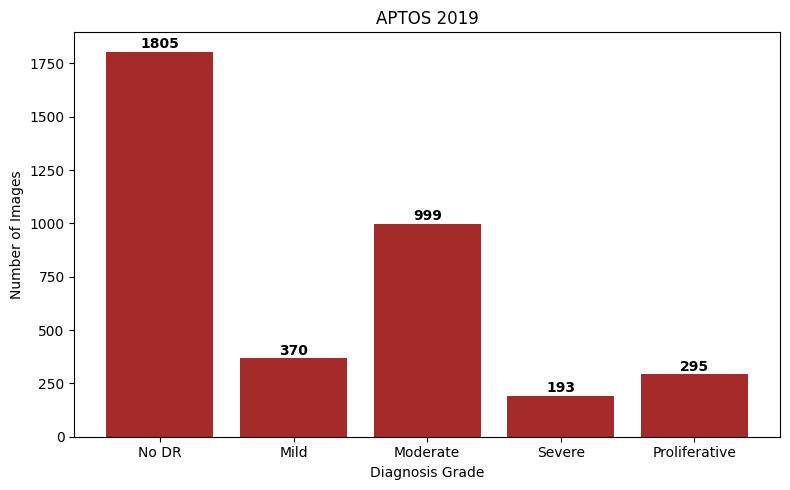

In [ ]:
import matplotlib.pyplot as plt

grade_labels = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative'
}

counts = train_df['diagnosis'].value_counts().sort_index()
labels=[]
for i in counts.index:
  labels.append(grade_labels[i])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color='brown')
ax.set_xlabel('Diagnosis Grade')
ax.set_ylabel('Number of Images')
ax.set_title('APTOS 2019')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
from PIL import Image

n_samples = 6  # images per class
grades = sorted(grade_labels.keys())

fig, axes = plt.subplots(len(grades), n_samples, figsize=(n_samples * 2.2, len(grades) * 2.2))

rng = np.random.default_rng(42)  # reproducible sampling

for row, grade in enumerate(grades):
    # Get all image ids for this grade
    subset = train_df[train_df['diagnosis'] == grade]['id_code'].values
    sample_ids = rng.choice(subset, size=min(n_samples, len(subset)), replace=False)

    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(image_dir, f"{img_id}.png")
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(grade_labels[grade], fontsize=11, rotation=0,
                          labelpad=40, va='center')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle('APTOS 2019 — Sample Images per Grade', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os

sizes = []

for img_id in train_df['id_code']:
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        sizes.append(img.size)

print("First 10 image sizes:")
print(sizes[:10])

print("\nUnique image sizes:")
print(len(set(sizes)))

First 10 image sizes:
[(3216, 2136), (3216, 2136), (2416, 1736), (1050, 1050), (2048, 1536), (3388, 2588), (2588, 1958), (3216, 2136), (2588, 1958), (2416, 1736)]

Unique image sizes:
17


In [ ]:
modes = []

for img_id in train_df['id_code'].sample(100, random_state=42):
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        modes.append(img.mode)

print(set(modes))

{'RGB'}


In [ ]:
import sys
sys.path.append('/content/RetinaGrade/src/preprocessing')

from preprocessor import RetinaPreprocessor
from quality_checker import ImageQualityAssessor

# **Add processed images**

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil


INPUT_DIR = '/content/RetinaGrade/data/train_images/'
GOOD_OUTPUT_DIR = '/content/RetinaGrade/data/processed_train_images/'
REJECTED_DIR = '/content/RetinaGrade/data/rejected_images/'

# Clean up old directories to start fresh (avoiding duplicate files)
if os.path.exists(GOOD_OUTPUT_DIR):
    shutil.rmtree(GOOD_OUTPUT_DIR)
if os.path.exists(REJECTED_DIR):
    shutil.rmtree(REJECTED_DIR)

# Create the directories again
os.makedirs(GOOD_OUTPUT_DIR, exist_ok=True)
os.makedirs(REJECTED_DIR, exist_ok=True)

assessor = ImageQualityAssessor()
preprocessor = RetinaPreprocessor(img_size=224)

QUALITY_THRESHOLD = 0.25


valid_extensions = ('.png', '.jpg', '.jpeg')
all_images = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_extensions)]

print(f" Starting processing of {len(all_images)} images with a lenient threshold ({QUALITY_THRESHOLD})...")

accepted_count = 0
rejected_count = 0

for img_name in tqdm(all_images, desc="Processing Images"):
    img_path = os.path.join(INPUT_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # Assess quality
    score, issues = assessor.assess_quality(img)

    if score >= QUALITY_THRESHOLD:
        # Image passed
        processed_img = preprocessor.preprocess_array(img, return_tensor=False)
        processed_img_uint8 = (processed_img * 255).astype(np.uint8)
        final_img_bgr = cv2.cvtColor(processed_img_uint8, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(GOOD_OUTPUT_DIR, img_name)
        cv2.imwrite(save_path, final_img_bgr)
        accepted_count += 1

    else:
        # Image rejected (score below threshold)
        dest_path = os.path.join(REJECTED_DIR, img_name)
        shutil.copy(img_path, dest_path)
        rejected_count += 1


print("\n" + "="*40)
print(" Process completed successfully!")
print(f" Total images: {len(all_images)}")
print(f" Accepted & Processed images: {accepted_count} (Saved to {GOOD_OUTPUT_DIR})")
print(f" Rejected images: {rejected_count} (Isolated to {REJECTED_DIR})")
print("="*40)

🚀 Starting processing of 3662 images with a lenient threshold (0.25)...


Processing Images:   9%|▉         | 344/3662 [01:18<18:13,  3.03it/s]